# Tutorial 2 — two IRDIS channels as partitions: HD 95086 b (VLT/SPHERE, K1/K2)

Ground-based data usually come in several pieces that could be reduced together or
apart: nights, epochs, the two IRDIS dual-band channels, IFS channels, chop states, the
pyNOMIC *image groups*.  klip-tpe calls each such piece a **partition**.  Every
partition gets its own KLIP basis and its own parameter block, and the optimizer also
searches *which* partitions to combine (the `drop1`/`drop2` dimensions) — a partition
that hurts the combined S/N gets dropped, one that helps stays.

Here the two channels of a SPHERE/IRDIS DB_K12 sequence of HD 95086 (63 frames each,
33.8° of field rotation, 2019-04-13) are the partitions.  HD 95086 b (0.62″, PA ≈ 145°)
is a real, faint (ΔK ≈ 12 mag) companion — a good test that the *validated* winner
does better than the default on a real signal rather than on injected ones only.

The 241×241 px crops (0.01225″/px, star at the centre) and the unsaturated flux frames
are fetched from the klip-tpe GitHub release (`datasets.fetch("sphere_hd95086")`).

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from klip_tpe import Runner, RunConfig, ValidationConfig, CalibrationConfig
from klip_tpe import datasets
from klip_tpe.instruments import generic
from klip_tpe.display import LiveDisplay
from klip_tpe.reducer import ReductionRequest

RUN_DIR = os.path.abspath("runs/hd95086_irdis")
files = datasets.fetch("sphere_hd95086")
inst = datasets.INSTRUMENT["sphere_hd95086"]
files, inst

({'cube_K1': '/root/.klip_tpe/data/hd95086_irdis_K1_cube.fits',
  'cube_K2': '/root/.klip_tpe/data/hd95086_irdis_K2_cube.fits',
  'psf_K1': '/root/.klip_tpe/data/hd95086_irdis_K1_psf.fits',
  'psf_K2': '/root/.klip_tpe/data/hd95086_irdis_K2_psf.fits',
  'angles': '/root/.klip_tpe/data/hd95086_irdis_angles.fits'},
 {'pxscale': 0.01225,
  'lam_m': 2.11e-06,
  'lam_m_K2': 2.251e-06,
  'diam_m': 8.2,
  'truenorth': 0.0,
  'dit_science': 96.0,
  'dit_flux': 0.837464,
  'nd_transmission': 0.0851})

## 1. Two partitions, one star flux per channel

The flux frames were taken with DIT 0.837 s through the ND_1.0 filter, the science
frames with DIT 96 s and no ND, so the star flux in science units is
`flux(template) × (96 / 0.837) / T_ND`.  `T_ND ≈ 0.085` at K1/K2 is the SPHERE ND_1.0
transmission (check the SPHERE user manual curves for your band; it only scales the
contrast axis).  Each channel has its own wavelength (2.110 / 2.251 µm), hence its own
λ/D and FWHM — `make_reducer` takes per-partition dicts.

In [2]:
angles = fits.getdata(files["angles"])
scale = inst["dit_science"] / inst["dit_flux"] / inst["nd_transmission"]
dsets, star_flux, lam = {}, {}, {}
for band in ("K1", "K2"):
    ds = generic.load_cube(files[f"cube_{band}"], angles, psf=files[f"psf_{band}"], name=band)
    dsets[band] = ds
    psf = ds.meta["psf"]
    star_flux[band] = float(psf[psf > 0].sum()) * scale
    lam[band] = inst["lam_m"] if band == "K1" else inst["lam_m_K2"]
    print(f"{band}: {ds.cube.shape}, PA {ds.angles.min():.1f}..{ds.angles.max():.1f} deg, star flux {star_flux[band]:.3g}")

red = generic.make_reducer(dsets, pxscale=inst["pxscale"], lam_m=lam, diam_m=inst["diam_m"], star_flux=star_flux,
                           max_workers="auto")
space = generic.make_space(red, k_klip_max=30)      # ranges scaled to the data (<=30 KL modes, <=7 frames/bin)
space.project = generic.make_guard(red, k_max=30)
objective, sampler = generic.default_config(red, known=[(0.62, 145.0)])     # keep injections off the planet
print(space.names)

K1: (63, 241, 241), PA 122.5..156.3 deg, star flux 2.91e+09


K2: (63, 241, 241), PA 122.5..156.3 deg, star flux 3.33e+09
  K1: 63 frames 241x241 px, PA span 33.8 deg, injection template (flux unit 2.91e+09), fwhm 4.45 px, lambda/D 4.33 px
  K2: 63 frames 241x241 px, PA span 33.8 deg, injection template (flux unit 3.33e+09), fwhm 4.75 px, lambda/D 4.62 px
['bin_K1', 'n_ang_K1', 'filter_K1', 'angsep_K1', 'anglemax_K1', 'corr_thresh_K1', 'noise_max_K1', 'coronoise_max_K1', 'k_klip_K1', 'bin_K2', 'n_ang_K2', 'filter_K2', 'angsep_K2', 'anglemax_K2', 'corr_thresh_K2', 'noise_max_K2', 'coronoise_max_K2', 'k_klip_K2', 'drop1', 'drop2']


`space.names` shows the structure: one block of nine parameters per channel
(`bin_K1 … k_klip_K1`, `bin_K2 … k_klip_K2`) plus the two selection slots.  A default
reduction of the 30–70 px (0.37–0.86″) annulus recovers the planet in both channels:

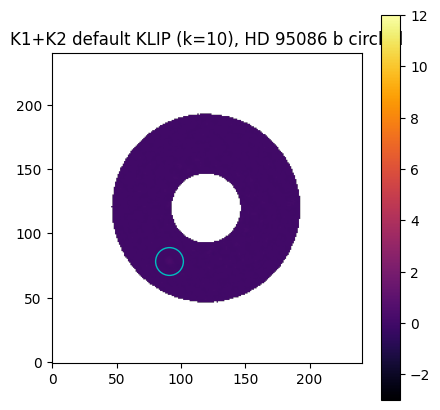

In [3]:
cfg0 = space.decode(space.default_vector())
res = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=30, outrad=70, k_klip=10)))
c = 120; rho = 0.62 / inst["pxscale"]; pa = np.deg2rad(145.0)
xb, yb = c - rho * np.sin(pa), c + rho * np.cos(pa)
plt.figure(figsize=(5, 5)); plt.imshow(res.image, origin="lower", cmap="inferno", vmin=-3, vmax=12)
plt.plot(xb, yb, "o", mfc="none", mec="c", ms=20); plt.title("K1+K2 default KLIP (k=10), HD 95086 b circled"); plt.colorbar();

## 2. Optimize

80 evaluations (20 warm-up), the best two validated on three fresh injection sets each,
on the 30–70 px annulus.  On a laptop this takes ~10 minutes; most of it is the live
panel, `display_every=2` halves that.  The contrast is calibrated to S/N ≈ 5 for the
default configuration.

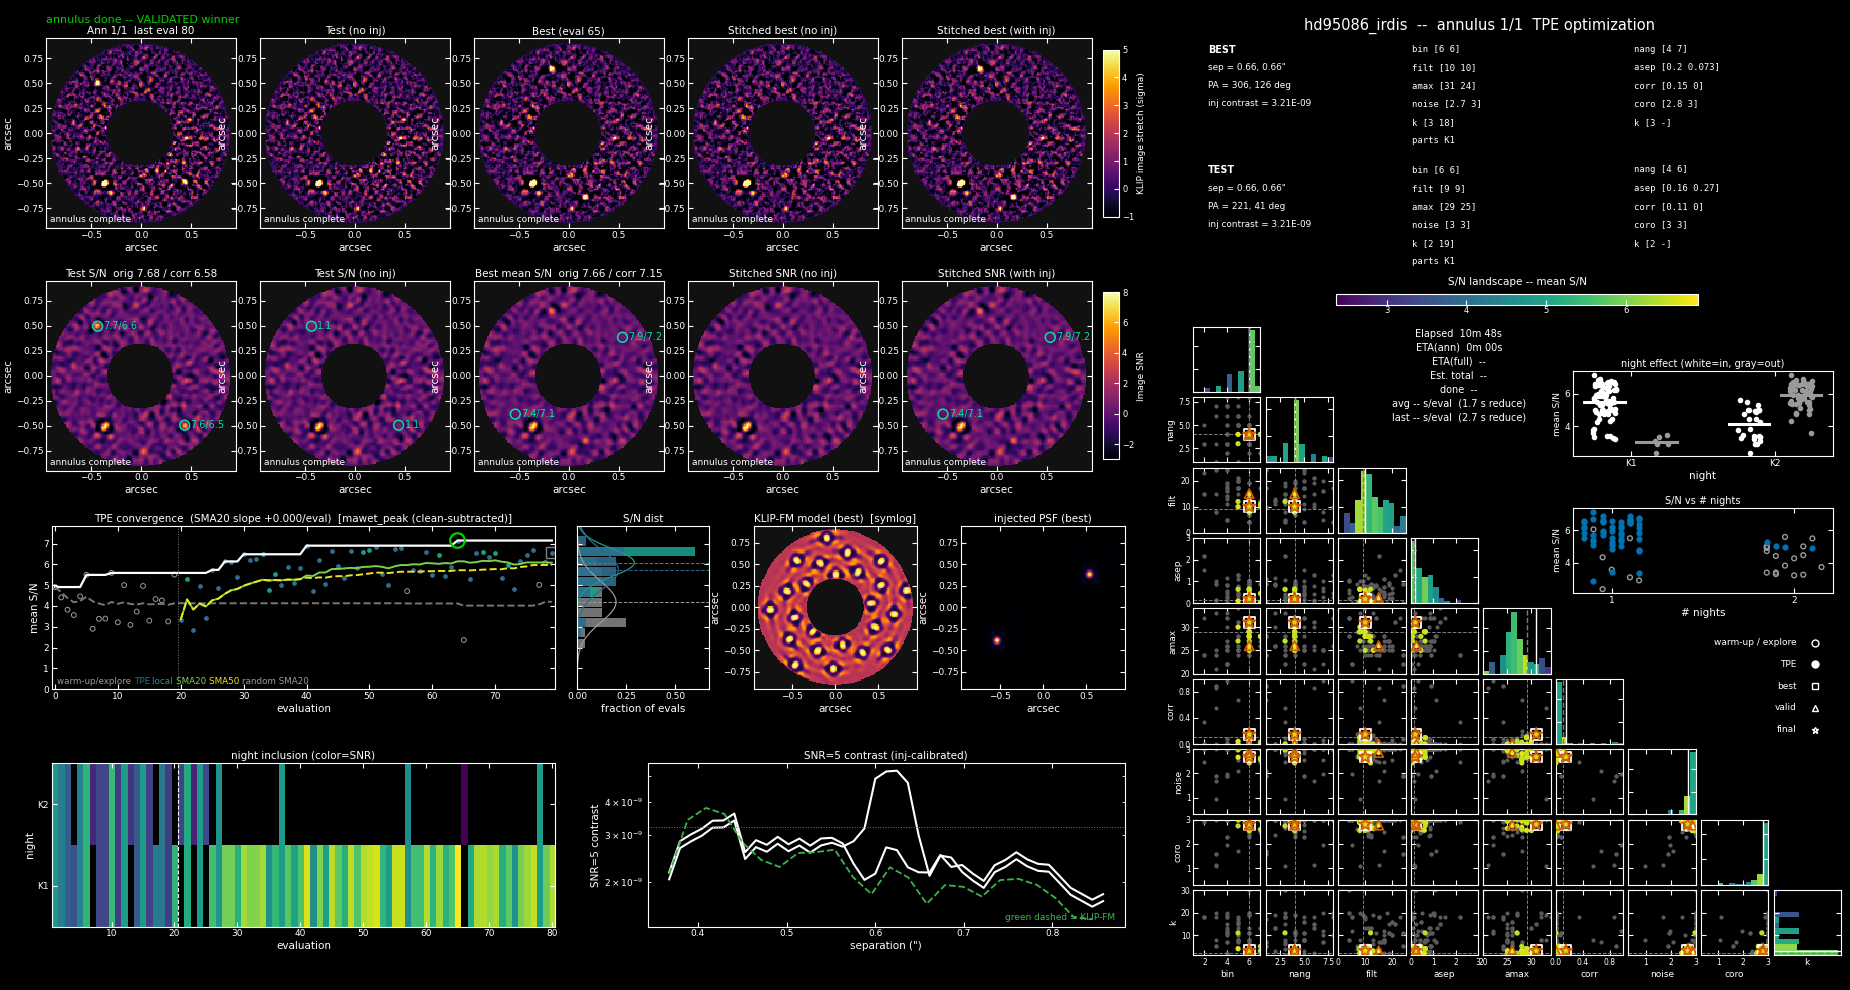

=== annulus 1/1: [30.0, 70.0] px, 2 sources, band 0.660-0.660"


  calibration k-scan: k_default = 13


  calibration trial 1: contrast=3.000e-05  median S/N=35.04


  calibration trial 2: contrast=4.281e-06  median S/N=28.10


  calibration trial 3: contrast=7.618e-07  median S/N=22.39


...

param_verify config 19/20 (eval 78, score 5.02)


param_verify config 20/20 (eval 24, score 4.97)


param_verify annulus 01: 20 configs; combine K~2.633E+07


run complete: 1 annuli, 80 evaluations


  [display] movie: ['/home/claude/klip-tpe-py/tutorials/runs/hd95086_irdis/opt_steps.gif', '/home/claude/klip-tpe-py/tutorials/runs/hd95086_irdis/opt_steps.mp4']
11.3 min


In [4]:
cfg = RunConfig(ann_edges=[30, 70], n_iter=80, n_init=20, seed=3,
                validation=ValidationConfig(n_top=2, n_valid=3),
                calibration=CalibrationConfig(target=(4.0, 6.0), aim=5.0, n_remeasure=2),
                defaults={"k_klip": 10}, fm_curve=True)
display = LiveDisplay(RUN_DIR, show="inline", window_scale=0.55, every=2, movie_every=10)
runner = Runner(red, space, objective, sampler, cfg, RUN_DIR, callbacks=[display])
t0 = time.time(); results = runner.run(); print(f"{(time.time() - t0) / 60:.1f} min")

## 3. What did it decide?

Besides the winner's parameters, the interesting outputs for partitions are: which
channels the winner keeps, the *night effect* panel (median S/N with each partition in
vs out), and the per-partition images in `products.pdf`.

Both channels were tuned, but the selection slots decide what enters the combination:
in this run only K1 survives — K2's speckle residuals cost the combined image more than
its photons add at this separation.  That is the decision you would otherwise make by
hand, made on the validated injection S/N instead.

In [5]:
r = results[0]
print(f"winner: eval {r.winner_index + 1}, validated {r.validated}, S/N {r.winner_score:.2f}  (search best {r.search_best_score:.2f})")
print("partitions kept:", r.partitions, " of", list(dsets))
for pid, blk in r.winner_config["per_partition"].items():                      # every block, kept or not
    keep = "kept   " if pid in r.partitions else "dropped"
    print(f"  {pid} ({keep}): " + "  ".join(f"{k}={v:.3g}" if isinstance(v, float) else f"{k}={v}"
                                            for k, v in blk.items() if k not in ("spat_mean", "temp_mean")))

winner: eval 65, validated True, S/N 7.46  (search best 7.15)
partitions kept: ['K1']  of ['K1', 'K2']
  K1 (kept   ): bin=6  n_ang=4  filter=10  angsep=0.196  anglemax=31  corr_thresh=0.148  noise_max=2.68  coronoise_max=2.81  k_klip=3
  K2 (dropped): bin=6  n_ang=7  filter=10  angsep=0.0726  anglemax=24  corr_thresh=0  noise_max=3  coronoise_max=3  k_klip=18


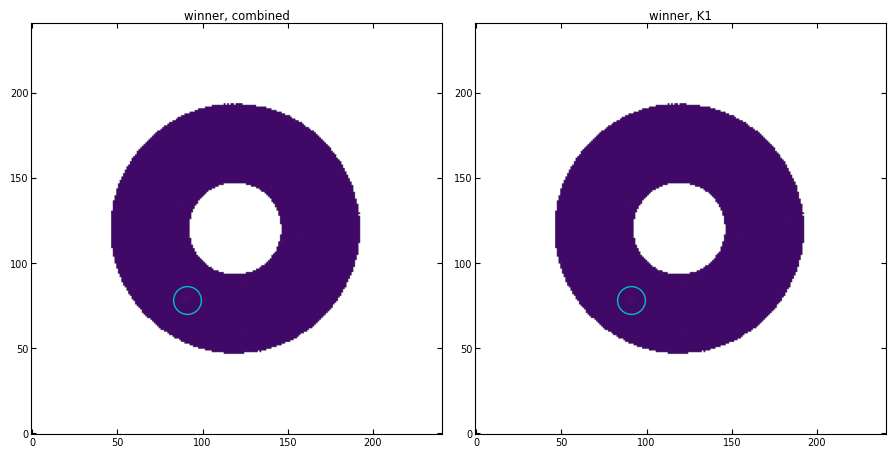

In [6]:
best_clean = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_clean.fits"))
parts = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_clean_partitions.fits"))
parts = parts[None] if parts.ndim == 2 else parts                              # one kept partition -> (ny, nx)
fig, ax = plt.subplots(1, 1 + parts.shape[0], figsize=(4.5 * (1 + parts.shape[0]), 4.4), squeeze=False)
ax = ax.ravel()
ax[0].imshow(best_clean, origin="lower", cmap="inferno", vmin=-3, vmax=12); ax[0].set_title("winner, combined")
for a_, im, pid in zip(ax[1:], parts, r.partitions):
    a_.imshow(im, origin="lower", cmap="inferno", vmin=-3, vmax=12); a_.set_title(f"winner, {pid}")
for a_ in ax:
    a_.plot(xb, yb, "o", mfc="none", mec="c", ms=20)
plt.tight_layout()

The planet's S/N in the default versus the optimized reduction, measured the same way
the optimizer scores its injections (matched-filter Mawet S/N with the small-sample
correction):

In [7]:
from klip_tpe.metrics import MawetPeakSNR
metric = MawetPeakSNR(pxscale=red.pxscale, fwhm=red.fwhm, kernel_fn=red.matched_filter_kernel)   # no 'known' exclusion here
snr_default = metric.per_source(res.image, None, [0.62], [145.0])[0]
snr_winner = metric.per_source(best_clean, None, [0.62], [145.0])[0]
print(f"HD 95086 b: S/N {snr_default:.1f} (default k=10)  ->  {snr_winner:.1f} (validated winner)")

HD 95086 b: S/N 12.2 (default k=10)  ->  19.3 (validated winner)


## 4. Contrast curves and the corner plot

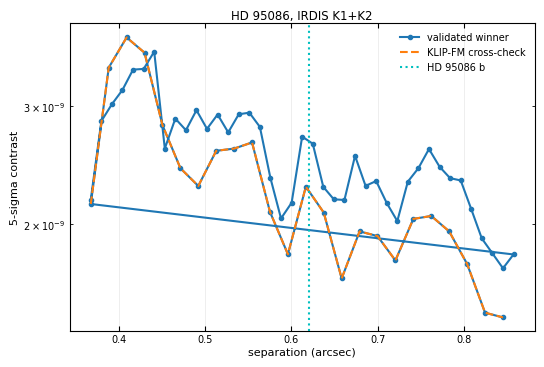

In [8]:
cc = np.loadtxt(os.path.join(RUN_DIR, "annulus01", "contrast_curve.txt"))
plt.figure(figsize=(6, 4)); plt.semilogy(cc[:, 0], cc[:, 1], "-o", ms=3, label="validated winner")
if r.fm_curve:
    plt.semilogy(r.fm_curve["r_as"], r.fm_curve["curve"], "--", label="KLIP-FM cross-check")
plt.axvline(0.62, color="c", ls=":", label="HD 95086 b"); plt.xlabel("separation (arcsec)"); plt.ylabel("5-sigma contrast")
# (the planet was passed as known= and is excluded from the noise rings, so it does not
#  inflate the limit at its own separation)
plt.legend(); plt.grid(alpha=.3); plt.title("HD 95086, IRDIS K1+K2");

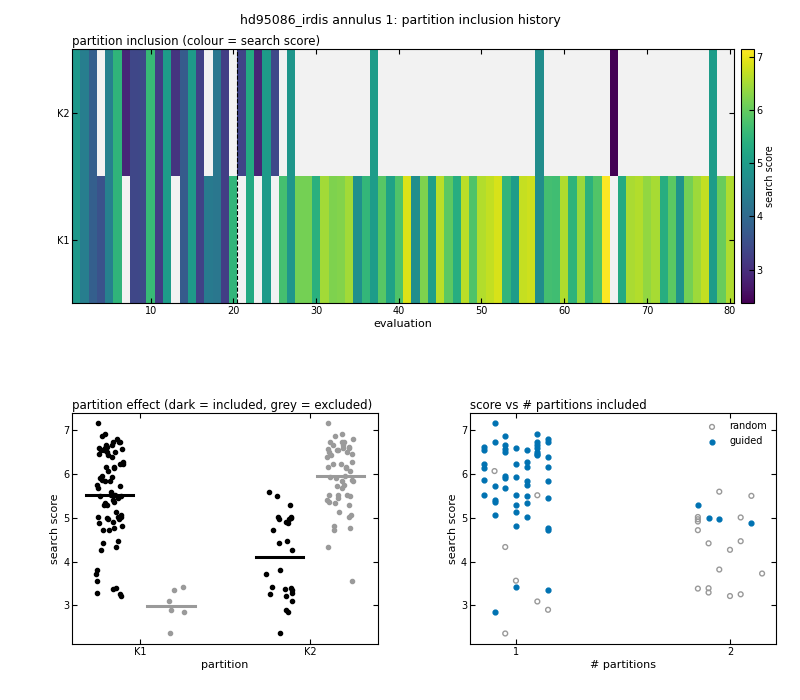

In [9]:
from IPython.display import Image
Image(filename=os.path.join(RUN_DIR, "annulus01", "partition_map.png"), width=800)

`annulus01/corner.pdf`, `importance.pdf` and `landscapes.pdf` show the sampled space per
partition; `annulus01/progress.gif` is the movie of this run.

## 5. Variations

* **More partitions** – add nights or epochs as more `Dataset`s; `--max-drop` /
  `make_space(max_drop=3)` gives the selection more slots when there are many.
* **One shared block** – `make_space(red, per_night=False)` tunes one parameter set for
  all partitions (fewer dimensions, faster convergence, less flexibility).
* **RDI** – give `load_cube(..., ref_cube=...)` a reference-star cube; the reducer then
  builds its KL basis from the references (`rdi_mode="rdi"`) or from references plus the
  angular-excluded science frames (`"ardi"`, default).  `datasets.fetch("sphere_sao206462")`
  has such a cube.
* **Terminal** –
  ```
  klip-tpe generic --cube hd95086_irdis_K1_cube.fits hd95086_irdis_K2_cube.fits --names K1 K2 \
      --angles hd95086_irdis_angles.fits --psf hd95086_irdis_K1_psf.fits hd95086_irdis_K2_psf.fits \
      --star-flux 2.91e9 2.66e9 --pxscale 0.01225 --lam 2.18e-6 --diam 8.2 --known 0.62 145 \
      --ann-edges 30 70 --n-iter 80 --n-init 20 --n-top 2 --n-valid 3 --run-dir runs/hd95086_cli --show
  ```